<a href="https://colab.research.google.com/github/vermalax/fake-insta-login/blob/main2/MalwareDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.Load Dataset and Examine Structure, Dimensions, and Data Types

##1.1 Importing Libraries

In [ ]:
!pip install pandas scikit-learn numpy matplotlib -U gdown

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import gdown
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


##1.2 Loading Dataset

In [2]:
file_id = '1KZT5BUm25X73QLNvTQiT-f9lw25TX3At'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'malware_data.csv', quiet=False)

df = pd.read_csv('malware_data.csv')


Downloading...
From: https://drive.google.com/uc?id=1KZT5BUm25X73QLNvTQiT-f9lw25TX3At
To: /content/malware_data.csv
100%|██████████| 6.51M/6.51M [00:00<00:00, 38.8MB/s]
/tmp/ipython-input-2910736850.py:4: DtypeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('malware_data.csv')


##1.3 Dataset Dimensions

In [3]:
print("Dataset (Rows, Columns):", df.shape)


Dataset (Rows, Columns): (15036, 216)


##1.4 Dataset Sample

In [4]:
df.head()

,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S


##1.5 Column Datatypes

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15036 entries, 0 to 15035
Columns: 216 entries, transact to class
dtypes: int64(214), object(2)
memory usage: 24.8+ MB


#2.Exploratory Data Analysis (EDA) with Statistical Summaries

##2.1 Class distribution (Malware vs Benign)

In [6]:
df['class'].value_counts()


,count
class,
B,9476
S,5560


##2.2 Class distribution as percentages


In [7]:
df['class'].value_counts(normalize=True) * 100

,proportion
class,
B,63.02208
S,36.97792


##2.3 Descriptive statistics for binary features

In [8]:
df.describe()

,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,SET_ORIENTATION,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS
count,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000,...,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000,15036.000000
mean,0.426443,0.446595,0.442671,0.413208,0.444932,0.486898,0.236632,0.330806,0.282389,0.312583,...,0.007050,0.233307,0.017425,0.004256,0.434424,0.666135,0.290835,0.016028,0.007050,0.044959
std,0.494576,0.497156,0.496719,0.492426,0.496975,0.499845,0.425029,0.470519,0.450177,0.463561,...,0.083669,0.422950,0.130852,0.065105,0.495698,0.471608,0.454163,0.125588,0.083669,0.207220
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transact,15036.0,0.426443,0.494576,0.0,0.0,0.0,1.0,1.0
onServiceConnected,15036.0,0.446595,0.497156,0.0,0.0,0.0,1.0,1.0
bindService,15036.0,0.442671,0.496719,0.0,0.0,0.0,1.0,1.0
attachInterface,15036.0,0.413208,0.492426,0.0,0.0,0.0,1.0,1.0
ServiceConnection,15036.0,0.444932,0.496975,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...
WRITE_EXTERNAL_STORAGE,15036.0,0.666135,0.471608,0.0,0.0,1.0,1.0,1.0
ACCESS_FINE_LOCATION,15036.0,0.290835,0.454163,0.0,0.0,0.0,1.0,1.0
SET_WALLPAPER_HINTS,15036.0,0.016028,0.125588,0.0,0.0,0.0,0.0,1.0
SET_PREFERRED_APPLICATIONS,15036.0,0.007050,0.083669,0.0,0.0,0.0,0.0,1.0


##2.4 Top 10 most frequently used numeric features



In [10]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
feature_sums = numeric_df.sum().sort_values(ascending=False)
feature_sums.head(10)

,0
INTERNET,13111
Binder,11892
IBinder,11788
android.os.IBinder,11787
Ljava.lang.Object.getClass,10943
ACCESS_NETWORK_STATE,10889
onBind,10321
android.content.pm.PackageInfo,10075
WRITE_EXTERNAL_STORAGE,10016
HttpUriRequest,9738


##2.5 Least used numeric features


In [11]:
feature_sums.tail(10)

,0
MOUNT_FORMAT_FILESYSTEMS,40
Context.bindService,38
android.intent.action.CALL_BUTTON,37
SET_PROCESS_LIMIT,33
INSTALL_LOCATION_PROVIDER,31
ADD_VOICEMAIL,30
BIND_TEXT_SERVICE,23
SET_ACTIVITY_WATCHER,16
Runtime.loadLibrary,15
BIND_VPN_SERVICE,8


## 2.6 Correlation between features and class



In [12]:
df_clean = df.copy()

df_clean.replace('?', np.nan, inplace=True)
df_clean = df_clean.apply(pd.to_numeric, errors='ignore')
df_clean['class_binary'] = df_clean['class'].map({'B': 0, 'S': 1})
correlations = df_clean.corr(numeric_only=True)['class_binary'].drop('class_binary')
correlations.sort_values(ascending=False).head(10)


/tmp/ipython-input-1325603783.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_clean = df_clean.apply(pd.to_numeric, errors='ignore')


,class_binary
SEND_SMS,0.545650
android.telephony.SmsManager,0.434843
READ_PHONE_STATE,0.408542
RECEIVE_SMS,0.387995
READ_SMS,0.370009
android.intent.action.BOOT_COMPLETED,0.313779
TelephonyManager.getLine1Number,0.305591
WRITE_SMS,0.267264
WRITE_HISTORY_BOOKMARKS,0.242051
TelephonyManager.getSubscriberId,0.241244


#3.Data Visualizations

##3.1 Class Distribution (Malware vs Benign)

In [ ]:
class_counts = df['class'].value_counts().rename_axis('Class').reset_index(name='Count')
class_counts['Percentage (%)'] = (class_counts['Count'] / class_counts['Count'].sum() * 100).round(2)
display(class_counts)

,Class,Count,Percentage (%)
0,B,9476,63.02
1,S,5560,36.98


/tmp/ipython-input-970965034.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


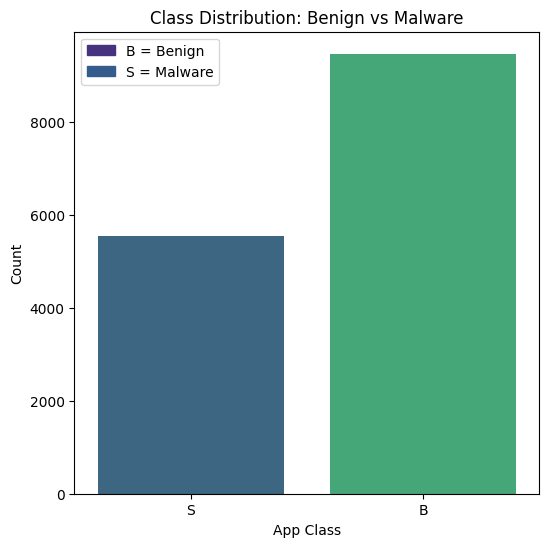

In [ ]:
plt.figure(figsize=(6, 6))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Class Distribution: Benign vs Malware')
plt.xlabel('App Class')
plt.ylabel('Count')

legend_labels = [
    Patch(color=sns.color_palette('viridis')[0], label='B = Benign'),
    Patch(color=sns.color_palette('viridis')[1], label='S = Malware')
]
plt.legend(handles=legend_labels, title='')
plt.show()


##3.2 Top 10 Most Common Features

In [13]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
feature_sums = numeric_df.sum().sort_values(ascending=False)
top_features = feature_sums.head(10)
print(top_features)

INTERNET                          13111
Binder                            11892
IBinder                           11788
android.os.IBinder                11787
Ljava.lang.Object.getClass        10943
ACCESS_NETWORK_STATE              10889
onBind                            10321
android.content.pm.PackageInfo    10075
WRITE_EXTERNAL_STORAGE            10016
HttpUriRequest                     9738
dtype: int64


/tmp/ipython-input-3168198114.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='magma')


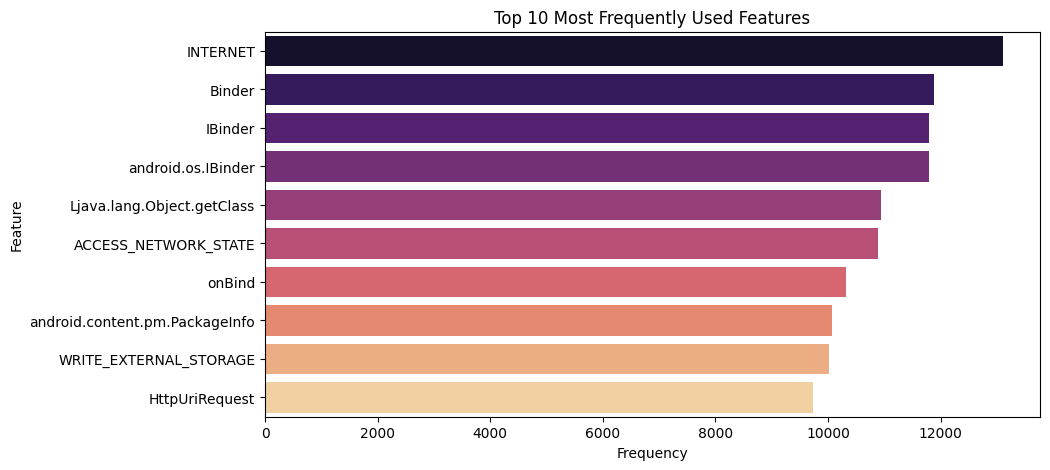

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette='magma')
plt.title('Top 10 Most Frequently Used Features')
plt.xlabel('Frequency')
plt.ylabel('Feature')
plt.show()


##3.3 Least Common Features


In [ ]:
bottom_features = feature_sums.tail(10)
print(bottom_features)

MOUNT_FORMAT_FILESYSTEMS             40
Context.bindService                  38
android.intent.action.CALL_BUTTON    37
SET_PROCESS_LIMIT                    33
INSTALL_LOCATION_PROVIDER            31
ADD_VOICEMAIL                        30
BIND_TEXT_SERVICE                    23
SET_ACTIVITY_WATCHER                 16
Runtime.loadLibrary                  15
BIND_VPN_SERVICE                      8
dtype: int64


/tmp/ipython-input-1993307570.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_features.values, y=bottom_features.index, palette='coolwarm')


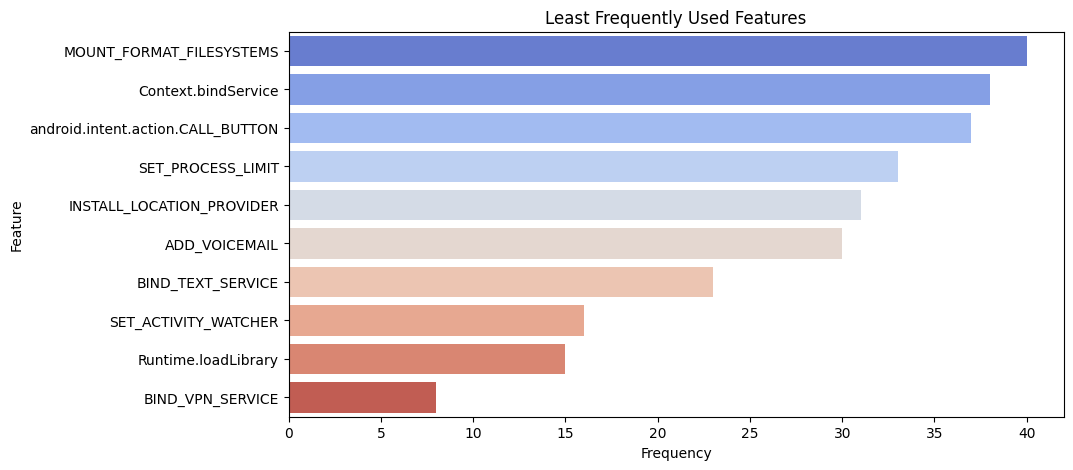

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=bottom_features.values, y=bottom_features.index, palette='coolwarm')
plt.title('Least Frequently Used Features')
plt.xlabel('Frequency')
plt.ylabel('Feature')
plt.show()


##3.4 Correlation Heatmap (Top 10 Features)

In [ ]:
df_clean = df.copy()
df_clean.replace('?', np.nan, inplace=True)
df_clean = df_clean.apply(pd.to_numeric, errors='ignore')
df_clean['class_binary'] = df_clean['class'].map({'B': 0, 'S': 1})

correlations = df_clean.corr(numeric_only=True)['class_binary'].drop('class_binary')
top_corr_features = correlations.sort_values(ascending=False).head(10)

print(top_corr_features)


/tmp/ipython-input-1960792460.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_clean = df_clean.apply(pd.to_numeric, errors='ignore')


SEND_SMS                                0.545650
android.telephony.SmsManager            0.434843
READ_PHONE_STATE                        0.408542
RECEIVE_SMS                             0.387995
READ_SMS                                0.370009
android.intent.action.BOOT_COMPLETED    0.313779
TelephonyManager.getLine1Number         0.305591
WRITE_SMS                               0.267264
WRITE_HISTORY_BOOKMARKS                 0.242051
TelephonyManager.getSubscriberId        0.241244
Name: class_binary, dtype: float64


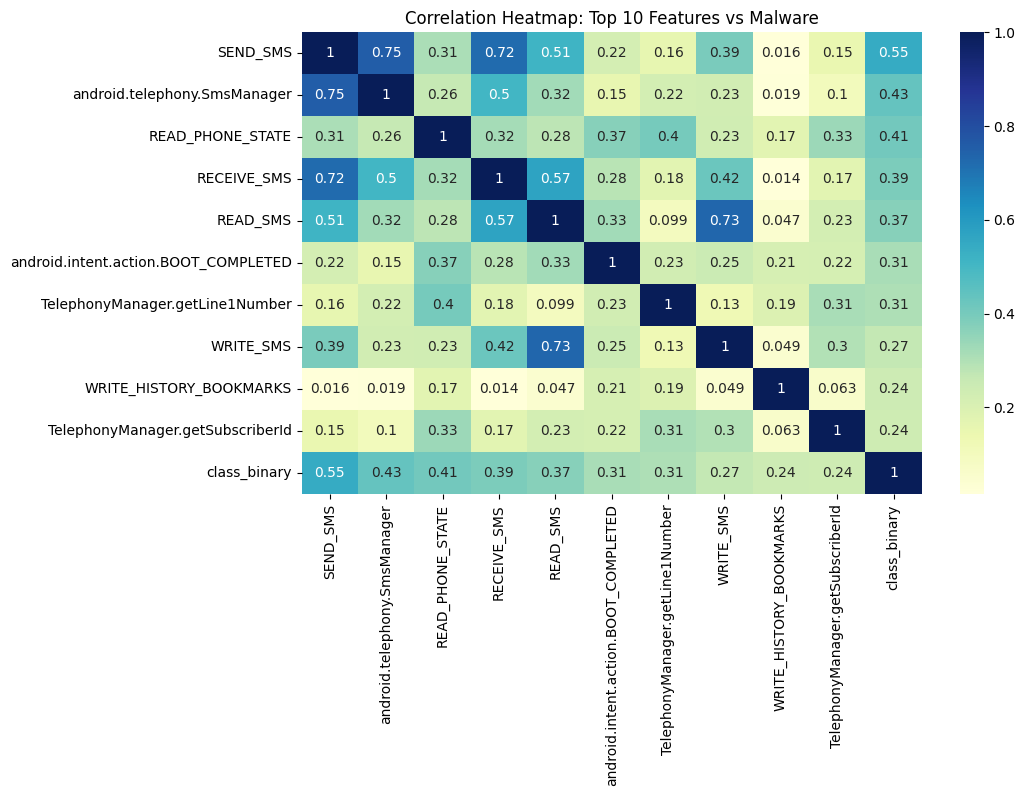

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean[top_corr_features.index.tolist() + ['class_binary']].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap: Top 10 Features vs Malware')
plt.show()


##3.5 Feature Usage Comparison by Class

In [ ]:
important_features = ['SEND_SMS', 'RECEIVE_SMS', 'READ_SMS', 'WRITE_SMS', 'READ_PHONE_STATE']
usage_summary = df.groupby('class')[important_features].agg(['sum', 'mean', 'count'])
usage_summary.columns = [f"{feat}_{stat}" for feat, stat in usage_summary.columns]
usage_summary = usage_summary.reset_index()
print("Feature Usage Summary by Class:")
display(usage_summary)


Feature Usage Summary by Class:


,class,SEND_SMS_sum,SEND_SMS_mean,SEND_SMS_count,RECEIVE_SMS_sum,RECEIVE_SMS_mean,RECEIVE_SMS_count,READ_SMS_sum,READ_SMS_mean,READ_SMS_count,WRITE_SMS_sum,WRITE_SMS_mean,WRITE_SMS_count,READ_PHONE_STATE_sum,READ_PHONE_STATE_mean,READ_PHONE_STATE_count
0,B,559,0.058991,9476,675,0.071233,9476,723,0.076298,9476,458,0.048333,9476,4563,0.481532,9476
1,S,2999,0.539388,5560,2139,0.384712,5560,2085,0.375000,5560,1244,0.223741,5560,4946,0.889568,5560


/tmp/ipython-input-1630618994.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='SEND_SMS', data=df, palette='viridis')


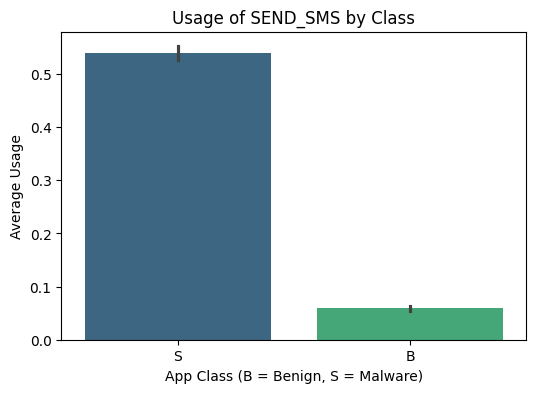

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x='class', y='SEND_SMS', data=df, palette='viridis')
plt.title('Usage of SEND_SMS by Class')
plt.xlabel('App Class (B = Benign, S = Malware)')
plt.ylabel('Average Usage')
plt.show()


/tmp/ipython-input-1223939175.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='RECEIVE_SMS', data=df, palette='viridis')


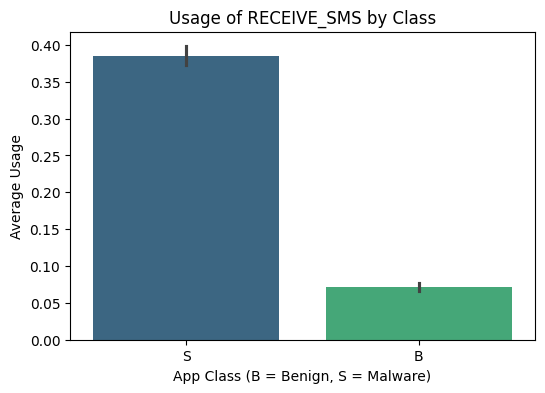

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x='class', y='RECEIVE_SMS', data=df, palette='viridis')
plt.title('Usage of RECEIVE_SMS by Class')
plt.xlabel('App Class (B = Benign, S = Malware)')
plt.ylabel('Average Usage')
plt.show()


/tmp/ipython-input-993217721.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='READ_SMS', data=df, palette='viridis')


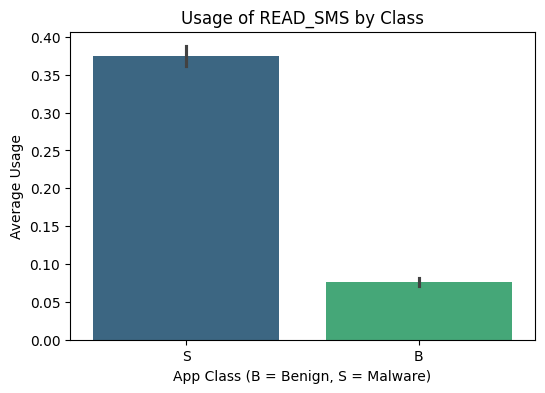

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x='class', y='READ_SMS', data=df, palette='viridis')
plt.title('Usage of READ_SMS by Class')
plt.xlabel('App Class (B = Benign, S = Malware)')
plt.ylabel('Average Usage')
plt.show()


/tmp/ipython-input-2019792384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='WRITE_SMS', data=df, palette='viridis')


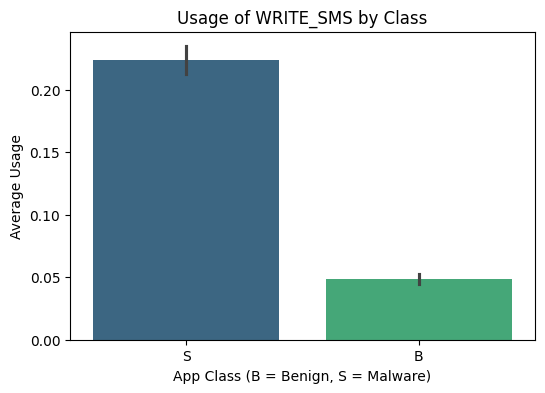

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x='class', y='WRITE_SMS', data=df, palette='viridis')
plt.title('Usage of WRITE_SMS by Class')
plt.xlabel('App Class (B = Benign, S = Malware)')
plt.ylabel('Average Usage')
plt.show()


/tmp/ipython-input-1723073354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='READ_PHONE_STATE', data=df, palette='viridis')


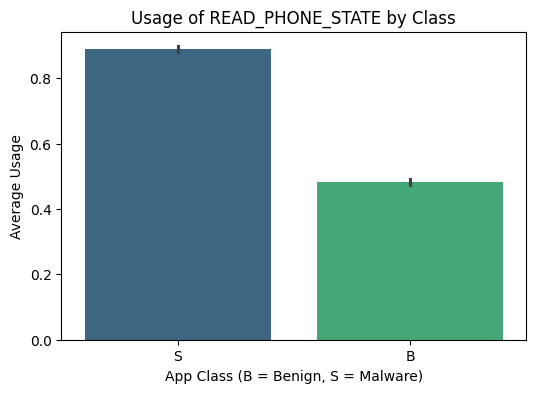

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x='class', y='READ_PHONE_STATE', data=df, palette='viridis')
plt.title('Usage of READ_PHONE_STATE by Class')
plt.xlabel('App Class (B = Benign, S = Malware)')
plt.ylabel('Average Usage')
plt.show()


##3.6 Usage of INSTALL_PACKAGES by Class (Benign vs Malware)

In [ ]:
install_pkg_table = df.groupby('class')['INSTALL_PACKAGES'].agg(['sum', 'mean', 'count']).reset_index()
install_pkg_table.columns = ['Class', 'Total Count (1s)', 'Mean Usage', 'Sample Size']
print("INSTALL_PACKAGES Usage by Class:")
display(install_pkg_table)


INSTALL_PACKAGES Usage by Class:


,Class,Total Count (1s),Mean Usage,Sample Size
0,B,227,0.023955,9476
1,S,825,0.148381,5560


/tmp/ipython-input-3895376233.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='INSTALL_PACKAGES', data=df, palette='rocket')


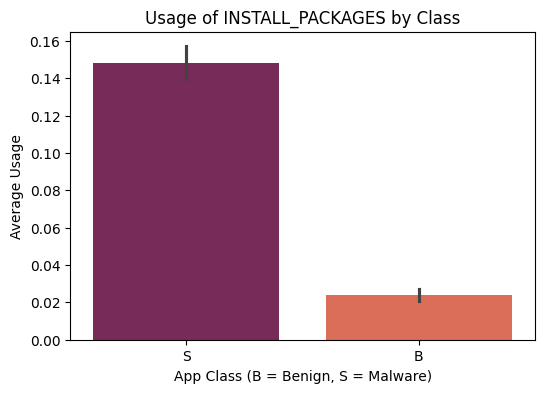

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x='class', y='INSTALL_PACKAGES', data=df, palette='rocket')
plt.title('Usage of INSTALL_PACKAGES by Class')
plt.xlabel('App Class (B = Benign, S = Malware)')
plt.ylabel('Average Usage')
plt.show()


#4.Analyzing Feature Distributions and Relationships Between Variables

##4.1 Feature Distributions by Class

In [ ]:
key_features = ['SEND_SMS', 'INSTALL_PACKAGES', 'RECEIVE_SMS', 'READ_PHONE_STATE']

for feature in key_features:
    feature_table = df.groupby('class')[feature].agg(['sum', 'mean', 'count']).reset_index()
    feature_table.columns = ['Class', 'Total Count (1s)', 'Mean Usage', 'Sample Size']
    print(f"Feature: {feature}")
    display(feature_table)


Feature: SEND_SMS


,Class,Total Count (1s),Mean Usage,Sample Size
0,B,559,0.058991,9476
1,S,2999,0.539388,5560


Feature: INSTALL_PACKAGES


,Class,Total Count (1s),Mean Usage,Sample Size
0,B,227,0.023955,9476
1,S,825,0.148381,5560


Feature: RECEIVE_SMS


,Class,Total Count (1s),Mean Usage,Sample Size
0,B,675,0.071233,9476
1,S,2139,0.384712,5560


Feature: READ_PHONE_STATE


,Class,Total Count (1s),Mean Usage,Sample Size
0,B,4563,0.481532,9476
1,S,4946,0.889568,5560


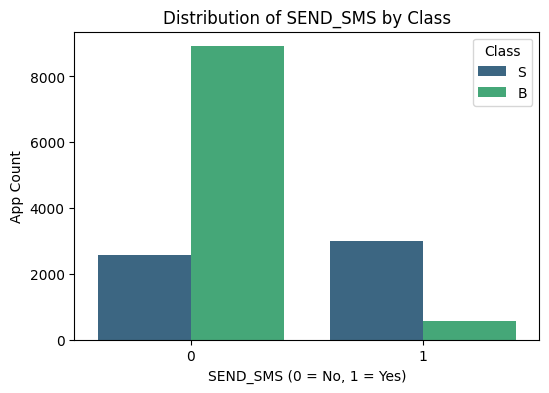

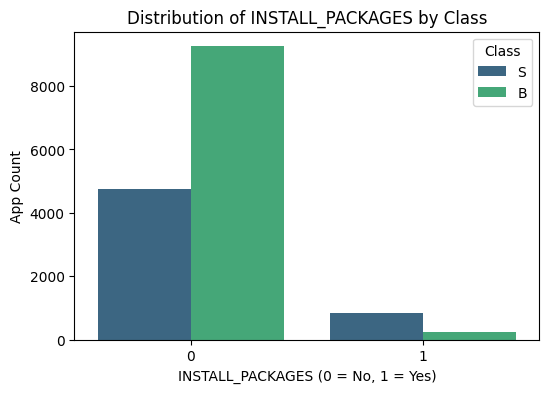

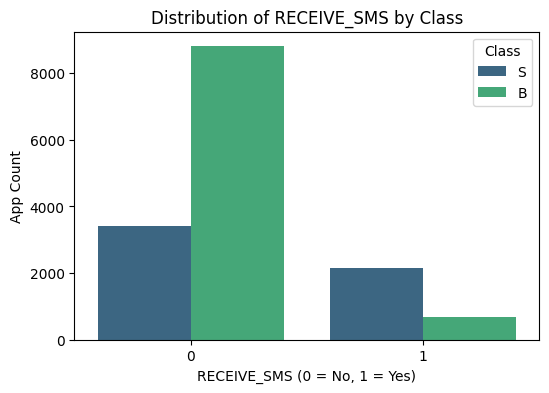

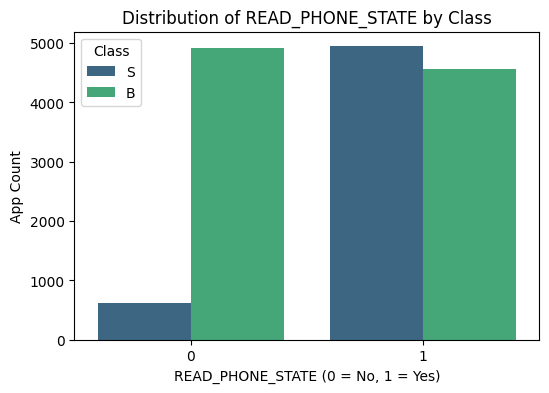

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='SEND_SMS', hue='class', data=df, palette='viridis')
plt.title('Distribution of SEND_SMS by Class')
plt.xlabel('SEND_SMS (0 = No, 1 = Yes)')
plt.ylabel('App Count')
plt.legend(title='Class')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='INSTALL_PACKAGES', hue='class', data=df, palette='viridis')
plt.title('Distribution of INSTALL_PACKAGES by Class')
plt.xlabel('INSTALL_PACKAGES (0 = No, 1 = Yes)')
plt.ylabel('App Count')
plt.legend(title='Class')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='RECEIVE_SMS', hue='class', data=df, palette='viridis')
plt.title('Distribution of RECEIVE_SMS by Class')
plt.xlabel('RECEIVE_SMS (0 = No, 1 = Yes)')
plt.ylabel('App Count')
plt.legend(title='Class')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='READ_PHONE_STATE', hue='class', data=df, palette='viridis')
plt.title('Distribution of READ_PHONE_STATE by Class')
plt.xlabel('READ_PHONE_STATE (0 = No, 1 = Yes)')
plt.ylabel('App Count')
plt.legend(title='Class')
plt.show()


##4.2 Relationship Between Two Features

Co-occurrence Table: SEND_SMS vs READ_SMS


READ_SMS,0,1
SEND_SMS,,
0,10609,869
1,1619,1939


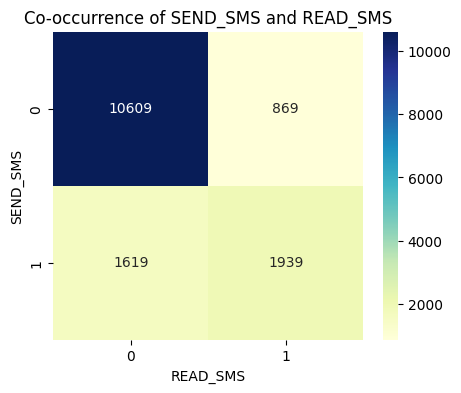

In [ ]:
cross_tab = pd.crosstab(index=df['SEND_SMS'], columns=df['READ_SMS'])
print("Co-occurrence Table: SEND_SMS vs READ_SMS")
display(cross_tab)

plt.figure(figsize=(5, 4))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Co-occurrence of SEND_SMS and READ_SMS')
plt.xlabel('READ_SMS')
plt.ylabel('SEND_SMS')
plt.show()


##4.3 Pairwise Feature Relationships

Average Feature Usage by Class:


,Class,SEND_SMS_Mean,RECEIVE_SMS_Mean,READ_PHONE_STATE_Mean
0,B,0.058991,0.071233,0.481532
1,S,0.539388,0.384712,0.889568


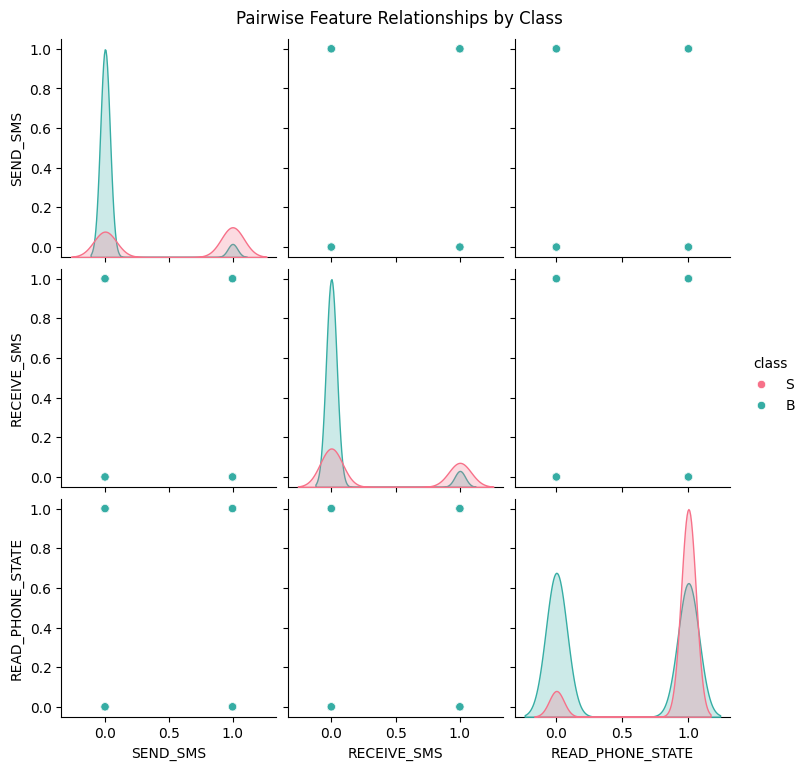

In [ ]:
subset = df[['SEND_SMS', 'RECEIVE_SMS', 'READ_PHONE_STATE', 'class']].copy()
subset['class'] = subset['class'].astype(str)

usage_means = subset.groupby('class')[['SEND_SMS', 'RECEIVE_SMS', 'READ_PHONE_STATE']].mean().reset_index()
usage_means.columns = ['Class', 'SEND_SMS_Mean', 'RECEIVE_SMS_Mean', 'READ_PHONE_STATE_Mean']

print("Average Feature Usage by Class:")
display(usage_means)

sns.pairplot(subset, hue='class', palette='husl')
plt.suptitle('Pairwise Feature Relationships by Class', y=1.02)
plt.show()


#5.Data Pre-processing

##5.1 Check Missing Values

In [ ]:
missing_values = df.isnull().sum()
missing_columns = missing_values[missing_values > 0]
print("Columns with Missing Values:")
display(missing_columns)


Columns with Missing Values:


,0


##5.2 Removing Rows having '?' Values


In [ ]:
question_mark_count = (df['TelephonyManager.getSimCountryIso'] == '?').sum()
print(f"Number of rows with '?': {question_mark_count}")


Number of rows with '?': 5


In [ ]:
df = df[df['TelephonyManager.getSimCountryIso'] != '?']
df['TelephonyManager.getSimCountryIso'] = pd.Categorical(df['TelephonyManager.getSimCountryIso']).codes.astype(int)
print(df['TelephonyManager.getSimCountryIso'].value_counts())
print(df['TelephonyManager.getSimCountryIso'].dtype)


TelephonyManager.getSimCountryIso
2    6994
0    5514
1    1330
3    1193
Name: count, dtype: int64
int64


In [ ]:
df['TelephonyManager.getSimCountryIso'].value_counts()


,count
TelephonyManager.getSimCountryIso,
2,6994
0,5514
1,1330
3,1193


##5.3 Check Duplicate Data

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_count}")


Number of Duplicate Rows: 6862


##5.4 Remove Duplicate Data

In [ ]:
df.drop_duplicates(inplace=True)
print(f"Remaining Duplicate Rows: {df.duplicated().sum()}")

Remaining Duplicate Rows: 0


#6.Encoding Target Variable Class

In [ ]:
df['class'] = df['class'].map({'B': 0, 'S': 1})

print(df['class'].value_counts())


class
0    6450
1    1719
Name: count, dtype: int64


In [ ]:
df.head()

,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1


#7.Feature Engineering

In [ ]:
df['sms_risk_count'] = df[['SEND_SMS', 'RECEIVE_SMS', 'READ_SMS', 'WRITE_SMS']].sum(axis=1)

df['install_risk_count'] = df[['INSTALL_PACKAGES', 'DELETE_PACKAGES',
                               'android.intent.action.PACKAGE_ADDED',
                               'android.intent.action.PACKAGE_REMOVED']].sum(axis=1)

df['location_data_risk_count'] = df[['ACCESS_FINE_LOCATION', 'ACCESS_COARSE_LOCATION',
                                     'READ_CONTACTS', 'READ_CALL_LOG']].sum(axis=1)

df['account_system_risk_count'] = df[['MANAGE_ACCOUNTS', 'WRITE_SETTINGS',
                                      'BIND_DEVICE_ADMIN', 'MODIFY_PHONE_STATE']].sum(axis=1)




In [ ]:
df['total_permissions'] = df.sum(axis=1)

dangerous_permissions = ['SEND_SMS', 'RECEIVE_SMS', 'READ_SMS', 'WRITE_SMS',
                         'INSTALL_PACKAGES', 'DELETE_PACKAGES',
                         'READ_CONTACTS', 'READ_CALL_LOG',
                         'ACCESS_FINE_LOCATION', 'ACCESS_COARSE_LOCATION']
df['dangerous_permission_count'] = df[dangerous_permissions].sum(axis=1)

communication_permissions = ['SEND_SMS', 'RECEIVE_SMS', 'READ_SMS', 'WRITE_SMS',
                              'CALL_PHONE', 'READ_CONTACTS']
df['communication_permission_count'] = df[communication_permissions].sum(axis=1)

df['dangerous_permission_ratio'] = df['dangerous_permission_count'] / df['total_permissions']

print("New features added successfully")


New features added successfully


In [ ]:
display(df[['sms_risk_count', 'install_risk_count', 'location_data_risk_count',
            'account_system_risk_count', 'total_permissions',
            'dangerous_permission_count', 'communication_permission_count',
            'dangerous_permission_ratio']].head())

,sms_risk_count,install_risk_count,location_data_risk_count,account_system_risk_count,total_permissions,dangerous_permission_count,communication_permission_count,dangerous_permission_ratio
0,1,0,0,0,13,1,1,0.076923
1,3,0,0,0,20,3,3,0.150000
2,1,0,0,0,15,1,1,0.066667
3,2,1,2,0,56,5,2,0.089286
4,0,0,2,0,31,2,0,0.064516


#8.Feature Importance

In [ ]:
X = df.drop('class', axis=1)
y = df['class']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False)


In [ ]:
print("\nTop 20 Important Features\n")
print(feature_importances.head(20))



Top 20 Important Features

                                         Feature  Importance
92             TelephonyManager.getSimCountryIso    0.110410
0                                       transact    0.039716
13                              READ_PHONE_STATE    0.033706
222                   dangerous_permission_ratio    0.030110
5                              android.os.Binder    0.029482
4                              ServiceConnection    0.028849
68                  TelephonyManager.getDeviceId    0.028786
2                                    bindService    0.026622
30               TelephonyManager.getLine1Number    0.026530
3                                attachInterface    0.023860
6                                       SEND_SMS    0.021669
1                             onServiceConnected    0.020497
215                               sms_risk_count    0.020144
43              TelephonyManager.getSubscriberId    0.019649
219                            total_permissions    0.019

In [ ]:
top_20_features = [
    'TelephonyManager.getSimCountryIso', 'transact', 'READ_PHONE_STATE', 'dangerous_permission_ratio',
    'android.os.Binder', 'ServiceConnection', 'TelephonyManager.getDeviceId', 'bindService',
    'TelephonyManager.getLine1Number', 'attachInterface', 'SEND_SMS', 'onServiceConnected',
    'sms_risk_count', 'TelephonyManager.getSubscriberId', 'total_permissions', 'WRITE_HISTORY_BOOKMARKS',
    'Landroid.content.Context.unregisterReceiver', 'READ_HISTORY_BOOKMARKS', 'dangerous_permission_count',
    'Ljava.lang.Class.getCanonicalName'
]

df_top20 = df[top_20_features + ['class']]
df_top20.head()


,TelephonyManager.getSimCountryIso,transact,READ_PHONE_STATE,dangerous_permission_ratio,android.os.Binder,ServiceConnection,TelephonyManager.getDeviceId,bindService,TelephonyManager.getLine1Number,attachInterface,...,onServiceConnected,sms_risk_count,TelephonyManager.getSubscriberId,total_permissions,WRITE_HISTORY_BOOKMARKS,Landroid.content.Context.unregisterReceiver,READ_HISTORY_BOOKMARKS,dangerous_permission_count,Ljava.lang.Class.getCanonicalName,class
0,2,0,1,0.076923,0,0,0,0,0,0,...,0,1,0,13,0,1,0,1,0,1
1,2,0,1,0.150000,0,0,0,0,0,0,...,0,3,0,20,0,1,0,3,0,1
2,2,0,1,0.066667,0,0,0,0,0,0,...,0,1,0,15,0,0,0,1,0,1
3,2,0,1,0.089286,0,0,1,0,1,0,...,0,2,1,56,0,0,0,5,0,1
4,2,0,1,0.064516,0,0,1,0,0,0,...,0,0,0,31,1,0,1,2,0,1


#9.Data Splitting: Training, Validation and Test

##9.1 Separate Features (X) and Target (y)


In [ ]:
X = df_top20.drop('class', axis=1)
y = df_top20['class']


##9.2 Split into Train (70%) and Temp (30%)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)


##9.3 Split Temp into Validation (15%) and Test (15%)


In [ ]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)


In [ ]:
print("Training Set Size:", X_train.shape[0])
print("Validation Set Size:", X_val.shape[0])
print("Test Set Size:", X_test.shape[0])

print("\nClass Distribution in Training Set")
print(y_train.value_counts(normalize=True))

print("\nClass Distribution in Validation Set")
print(y_val.value_counts(normalize=True))

print("\nClass Distribution in Test Set")
print(y_test.value_counts(normalize=True))



Training Set Size: 5718
Validation Set Size: 1225
Test Set Size: 1226

Class Distribution in Training Set
class
0    0.789612
1    0.210388
Name: proportion, dtype: float64

Class Distribution in Validation Set
class
0    0.789388
1    0.210612
Name: proportion, dtype: float64

Class Distribution in Test Set
class
0    0.78956
1    0.21044
Name: proportion, dtype: float64
